# K-Means sobre gaming y salud mental

Este notebook replica la metodologia usada en `Claustering_jerarquico.ipynb`, pero utilizando **K-Means** sobre `Dataset/data_preprocesada.csv`.

Incluye:
1. Preparacion de datos y estandarizacion.
2. Seleccion de `k` con **Silhouette Score**.
3. Entrenamiento del modelo final K-Means.
4. Estadisticas solicitadas: Silhouette, tamano de clusters y distancia a centroides.
5. Analisis post-hoc con las variables objetivo usadas en SVM (`addiction_class` y `addiction_level_original`, cuando existan).
6. Guardado del artefacto `.pkl`.


In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)


In [2]:
# Rutas
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'Models' else Path.cwd().resolve()
DATA_PATH = ROOT / 'Dataset' / 'data_preprocesada.csv'
MODEL_PATH = ROOT / 'Models' / 'kmeans_addiction.pkl'

print(f'Data path: {DATA_PATH}')
print(f'Model path: {MODEL_PATH}')


Data path: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Dataset/data_preprocesada.csv
Model path: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Models/kmeans_addiction.pkl


In [3]:
# Carga de datos
df = pd.read_csv(DATA_PATH)
print('Shape original:', df.shape)
print('Columnas:', len(df.columns))

target_cols = [c for c in ['addiction_class', 'addiction_level_original'] if c in df.columns]
print('Variables objetivo disponibles para analisis post-hoc:', target_cols)

df.head(3)


Shape original: (200000, 39)
Columnas: 39
Variables objetivo disponibles para analisis post-hoc: ['addiction_class', 'addiction_level_original']


,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,academic_performance,work_productivity,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,headset_usage,microtransactions_spending,parental_supervision,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality,gaming_intensity_index,online_social_ratio,gaming_screen_share,gender_Female,gender_Male,gender_Other,addiction_class,addiction_level_original,partition
0,1.106716,-1.646065,-0.113295,0.180454,0.694010,-1.156370,-0.514881,-0.944476,-0.866113,-0.077578,0.494208,-0.493029,-1.473080,0.548159,-1.205205,-0.807595,-1.088860,-0.316046,-0.443108,0.579753,-1.269294,1.0,2.636096,-1.583714,-1.079957,-0.848070,0.358027,0.408814,1.057543,1.565007,-0.421056,-0.289764,1.272006,1,0,0,bajo,2.02,train
1,0.369081,-0.908864,0.623986,1.244874,0.555363,1.463923,-0.672478,-0.283464,0.872712,-2.161633,-1.694914,-1.208658,0.534230,0.148365,-1.160560,-0.807595,2.910225,0.863591,-1.586484,-0.469067,0.948754,1.0,-0.321155,0.632438,0.593630,-0.349886,0.894010,-0.011810,0.259967,-1.221489,1.433143,-0.467818,1.631113,1,0,0,moderado,5.85,train
2,-0.663607,-0.884648,-0.879776,-1.061369,1.387242,0.260185,0.136521,0.613624,-0.866113,1.867267,-1.026205,-1.969014,-0.845795,0.398236,-1.026622,-0.360200,-0.726192,1.418714,-0.720290,1.104163,0.948754,1.0,-0.919139,1.265625,0.287975,0.349138,-1.437013,0.378037,0.329322,1.565007,-1.050771,-0.411616,-1.482531,0,1,0,bajo,0.08,train


In [4]:
# Preparacion de features para clustering
# Las variables objetivo y particion NO se usan para entrenar K-Means.
exclude_cols = ['addiction_class', 'addiction_level_original', 'partition']
existing_exclusions = [c for c in exclude_cols if c in df.columns]

df_model = df.drop(columns=existing_exclusions, errors='ignore')
X = df_model.select_dtypes(include=[np.number]).copy()
X = X.fillna(X.median(numeric_only=True))

print('Columnas excluidas del entrenamiento:', existing_exclusions)
print('Shape de X:', X.shape)


Columnas excluidas del entrenamiento: ['addiction_class', 'addiction_level_original', 'partition']
Shape de X: (200000, 36)


In [5]:
# Muestreo para seleccion eficiente de k con Silhouette
SAMPLE_SIZE = 5000
RANDOM_STATE = 42

if len(X) > SAMPLE_SIZE:
    sample_idx = X.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).index
    X_sample = X.loc[sample_idx].copy()
else:
    sample_idx = X.index
    X_sample = X.copy()

scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

print('Muestra para tuning:', X_sample.shape)


Muestra para tuning: (5000, 36)


In [6]:
# Seleccion de k con Silhouette
k_values = list(range(2, 11))
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_sample_scaled)
    score_k = silhouette_score(X_sample_scaled, labels_k)
    silhouette_scores.append(score_k)
    print(f'k={k} -> silhouette={score_k:.4f}')

silhouette_df = pd.DataFrame({'k': k_values, 'silhouette': silhouette_scores})
best_k = int(silhouette_df.loc[silhouette_df['silhouette'].idxmax(), 'k'])
print(f'\nMejor k segun Silhouette: {best_k}')
silhouette_df


k=2 -> silhouette=0.0609
k=3 -> silhouette=0.0512


k=4 -> silhouette=0.0596
k=5 -> silhouette=0.0615


k=6 -> silhouette=0.0538
k=7 -> silhouette=0.0424


k=8 -> silhouette=0.0364
k=9 -> silhouette=0.0368


k=10 -> silhouette=0.0365

Mejor k segun Silhouette: 5


,k,silhouette
0,2,0.060878
1,3,0.051231
2,4,0.059631
3,5,0.061468
4,6,0.053805
5,7,0.042428
6,8,0.036408
7,9,0.036813
8,10,0.036504


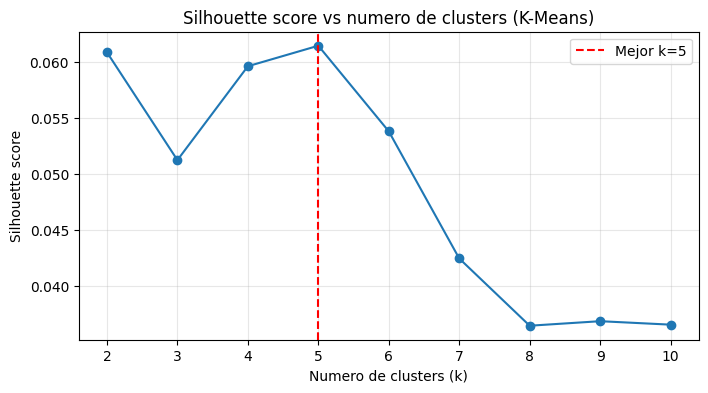

In [7]:
# Curva de Silhouette
plt.figure(figsize=(8, 4))
plt.plot(silhouette_df['k'], silhouette_df['silhouette'], marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Mejor k={best_k}')
plt.title('Silhouette score vs numero de clusters (K-Means)')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Silhouette score')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [8]:
# Entrenamiento final con mejor k (sobre la muestra metodologica)
final_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
final_labels = final_model.fit_predict(X_sample_scaled)

sil_final = silhouette_score(X_sample_scaled, final_labels)
print(f'Silhouette Score final: {sil_final:.4f}')

cluster_sizes = pd.Series(final_labels, name='cluster').value_counts().sort_index()
cluster_props = (cluster_sizes / cluster_sizes.sum()).rename('proporcion')
print('\nTamano de clusters:')
display(pd.concat([cluster_sizes.rename('cantidad'), cluster_props], axis=1))


Silhouette Score final: 0.0615

Tamano de clusters:


,cantidad,proporcion
cluster,,
0,215,0.0430
1,1896,0.3792
2,1854,0.3708
3,919,0.1838
4,116,0.0232


In [9]:
# Distancia a centroides por cluster (compactacion intra-cluster)
X_df_scaled = pd.DataFrame(X_sample_scaled, columns=X.columns)
X_df_scaled['cluster'] = final_labels
centroids = pd.DataFrame(final_model.cluster_centers_, columns=X.columns)

dist_df = pd.DataFrame({'cluster': final_labels})
dist_df['dist_to_centroid'] = np.linalg.norm(
    X_sample_scaled - final_model.cluster_centers_[final_labels], axis=1
)

compact_stats = dist_df.groupby('cluster')['dist_to_centroid'].agg(['mean', 'median', 'std', 'max']).round(4)
print('Estadisticas de compactacion intra-cluster (distancia al centroide):')
display(compact_stats)


Estadisticas de compactacion intra-cluster (distancia al centroide):


,mean,median,std,max
cluster,,,,
0,5.6027,5.5400,0.7638,9.6958
1,5.4590,5.4221,0.6341,7.9813
2,5.4648,5.4104,0.6455,8.5161
3,5.6949,5.6509,0.6444,8.4105
4,6.1536,6.0586,0.7755,8.2976


In [10]:
# Relacion post-hoc con variables objetivo de SVM (si existen)
analysis_df = df.loc[X_sample.index, target_cols].copy() if target_cols else pd.DataFrame(index=X_sample.index)
analysis_df['cluster'] = final_labels

if 'addiction_class' in analysis_df.columns:
    print('Distribucion de addiction_class dentro de cada cluster (proporcion por fila):')
    ctab_class = pd.crosstab(analysis_df['cluster'], analysis_df['addiction_class'], normalize='index').round(4)
    display(ctab_class)

if 'addiction_level_original' in analysis_df.columns:
    print('Resumen de addiction_level_original por cluster:')
    level_stats = analysis_df.groupby('cluster')['addiction_level_original'].agg(['mean', 'median', 'std', 'min', 'max']).round(4)
    display(level_stats)


Distribucion de addiction_class dentro de cada cluster (proporcion por fila):


addiction_class,alto,bajo,moderado
cluster,,,
0,0.0419,0.6047,0.3535
1,0.0016,0.7574,0.2410
2,0.0016,0.7600,0.2384
3,0.2992,0.0381,0.6627
4,0.0776,0.5862,0.3362


Resumen de addiction_level_original por cluster:


,mean,median,std,min,max
cluster,,,,,
0,2.8307,2.460,1.9243,0.00,10.00
1,2.0602,1.985,1.3682,0.00,10.00
2,1.9924,1.895,1.3534,0.00,6.94
3,5.8108,5.560,1.8411,1.67,10.00
4,2.8659,2.495,2.2802,0.00,10.00


In [11]:
# Guardar artefacto
artifact = {
    'model': final_model,
    'scaler': scaler,
    'best_k': best_k,
    'silhouette_scores': silhouette_df,
    'feature_columns': X.columns.tolist(),
    'sample_index': X_sample.index.to_list(),
    'sample_size': int(len(X_sample)),
    'random_state': RANDOM_STATE,
    'method': 'KMeans',
    'metrics': {
        'silhouette': float(sil_final),
        'cluster_sizes': cluster_sizes.to_dict(),
    },
    'target_columns_used_for_posthoc': target_cols,
}

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, MODEL_PATH)
print(f'Artefacto guardado en: {MODEL_PATH}')


Artefacto guardado en: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Models/kmeans_addiction.pkl


## Evaluacion tipo clasificacion (referencia con `addiction_class`)

Aunque K-Means es un metodo no supervisado, para comparar con el enfoque de `svm_clasificacion.ipynb` se construye una evaluacion post-hoc:

- Se asigna cada cluster a una clase por **mayoria** (`cluster -> clase`).
- Luego se calculan metricas de clasificacion sobre la muestra: **accuracy, precision, recall, f1-score** y matriz de confusion.


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

if 'addiction_class' not in target_cols:
    print("No existe 'addiction_class' en el dataset; no se pueden calcular metricas tipo clasificacion.")
else:
    eval_df = pd.DataFrame({
        'cluster': final_labels,
        'addiction_class': df.loc[X_sample.index, 'addiction_class'].values
    })

    # Mapeo cluster -> clase mayoritaria
    cluster_to_class = (
        eval_df.groupby('cluster')['addiction_class']
        .agg(lambda s: s.value_counts().idxmax())
        .to_dict()
    )

    y_true = eval_df['addiction_class'].values
    y_pred = eval_df['cluster'].map(cluster_to_class).values

    labels = sorted(pd.unique(y_true))

    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average='macro', zero_division=0
    )
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average='weighted', zero_division=0
    )

    print('Mapeo Cluster -> Clase mayoritaria:')
    print(cluster_to_class)

    print()
    print('Metricas globales (post-hoc):')
    print(f'Accuracy            : {acc:.4f}')
    print(f'Precision (macro)   : {p_macro:.4f}')
    print(f'Recall (macro)      : {r_macro:.4f}')
    print(f'F1-score (macro)    : {f1_macro:.4f}')
    print(f'Precision (weighted): {p_weight:.4f}')
    print(f'Recall (weighted)   : {r_weight:.4f}')
    print(f'F1-score (weighted) : {f1_weight:.4f}')

    print()
    print('Reporte por clase:')
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    # Guardar para uso posterior
    posthoc_metrics = {
        'accuracy': float(acc),
        'precision_macro': float(p_macro),
        'recall_macro': float(r_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(p_weight),
        'recall_weighted': float(r_weight),
        'f1_weighted': float(f1_weight),
        'cluster_to_class': cluster_to_class,
    }


Mapeo Cluster -> Clase mayoritaria:
{0: 'bajo', 1: 'bajo', 2: 'bajo', 3: 'moderado', 4: 'bajo'}

Metricas globales (post-hoc):
Accuracy            : 0.7304
Precision (macro)   : 0.4694
Recall (macro)      : 0.4546
F1-score (macro)    : 0.4431
Precision (weighted): 0.6741
Recall (weighted)   : 0.7304
F1-score (weighted) : 0.6789

Reporte por clase:
              precision    recall  f1-score   support

        alto       0.00      0.00      0.00       299
        bajo       0.75      0.99      0.85      3078
    moderado       0.66      0.38      0.48      1623

    accuracy                           0.73      5000
   macro avg       0.47      0.45      0.44      5000
weighted avg       0.67      0.73      0.68      5000



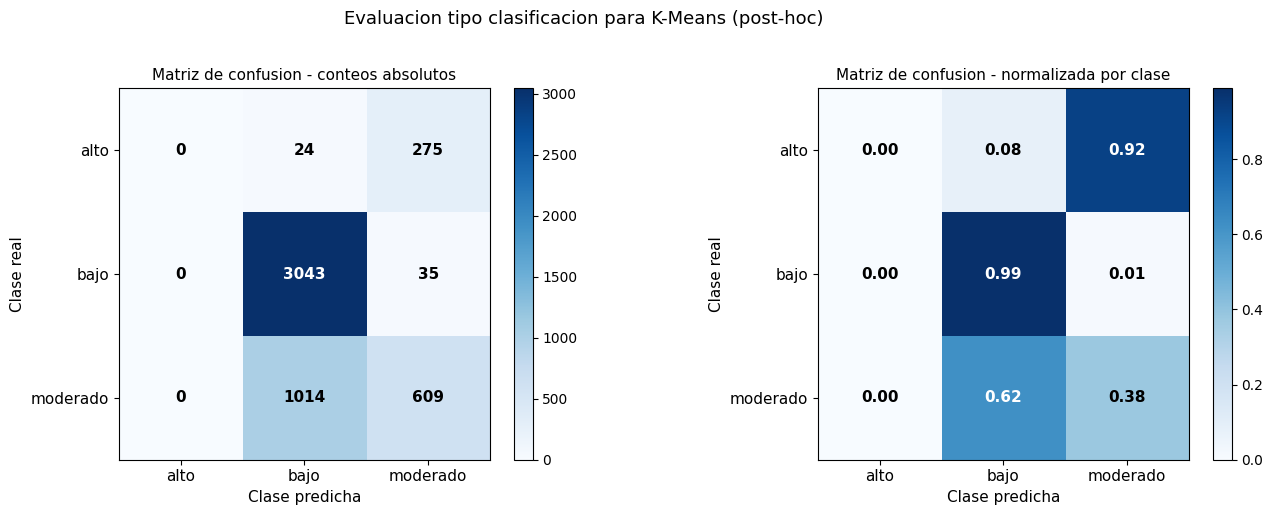

In [13]:
if 'addiction_class' in target_cols:
    labels = sorted(pd.unique(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, matrix, title, fmt in [
        (axes[0], cm,      'Matriz de confusion - conteos absolutos', 'd'),
        (axes[1], cm_norm, 'Matriz de confusion - normalizada por clase', '.2f'),
    ]:
        im = ax.imshow(matrix, cmap='Blues')
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=11)
        ax.set_yticklabels(labels, fontsize=11)
        ax.set_xlabel('Clase predicha', fontsize=11)
        ax.set_ylabel('Clase real', fontsize=11)
        ax.set_title(title, fontsize=11)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        for i in range(len(labels)):
            for j in range(len(labels)):
                val = matrix[i, j]
                txt = f"{val:{fmt}}"
                color = 'white' if matrix[i, j] > matrix.max() * 0.6 else 'black'
                ax.text(j, i, txt, ha='center', va='center', fontsize=11, color=color, fontweight='bold')

    plt.suptitle('Evaluacion tipo clasificacion para K-Means (post-hoc)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


In [14]:
# Actualizar artefacto con metricas tipo clasificacion (si existen)
if 'addiction_class' in target_cols:
    artifact['classification_like_metrics'] = posthoc_metrics
    joblib.dump(artifact, MODEL_PATH)
    print('Artefacto actualizado con metricas tipo clasificacion en:', MODEL_PATH)
else:
    print("No se actualizo artifact['classification_like_metrics'] porque no existe addiction_class.")


Artefacto actualizado con metricas tipo clasificacion en: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Models/kmeans_addiction.pkl


## Conclusiones del modelo K-Means

El modelo K-Means aplicado al dataset de gaming y salud mental identifica una segmentacion util en **5 clusters** (segun Silhouette en la metodologia aplicada), con una estructura donde coexisten grupos mayoritarios y subgrupos de menor tamano. Esto refuerza la idea de que los patrones de juego no son homogeneos y que existen perfiles conductuales diferenciados.

Desde la perspectiva de salud mental, el cruce post-hoc con `addiction_class` muestra que los clusters capturan parcialmente diferencias entre niveles de adiccion (`bajo`, `moderado`, `alto`). Las metricas tipo clasificacion (accuracy, precision, recall y f1-score) deben interpretarse como una **aproximacion descriptiva**, no como evaluacion supervisada estricta, ya que K-Means no optimiza contra etiquetas reales.

En conjunto, los resultados son consistentes con el objetivo del proyecto: segmentar poblaciones gamers para detectar patrones asociados a mayor vulnerabilidad psicosocial. Como siguiente paso, se recomienda perfilar cada cluster con variables clave (intensidad de juego, sueno, estres, exposicion toxica, socializacion online) para transformar estos segmentos en acciones concretas de prevencion y acompanamiento.